In [1]:
import os 


train_root = 'Train'
val_root = 'Val'

train_GT_root = 'YOLO Annotations/Train'
val_GT_root = 'YOLO Annotations/Val'

image_types = ('high', 'low')

print('Train Data Info')
print(len(os.listdir(os.path.join(train_root, 'high'))))
print(len(os.listdir(os.path.join(train_root, 'low'))))
print(len(os.listdir(os.path.join(train_GT_root, 'high/Labels'))))
print(len(os.listdir(os.path.join(train_GT_root, 'low/Labels'))))

print('\nVal Data Info')
print(len(os.listdir(os.path.join(val_root, 'high'))))
print(len(os.listdir(os.path.join(val_root, 'low'))))
print(len(os.listdir(os.path.join(val_GT_root, 'YOLO Annotations (high)/Labels'))))
print(len(os.listdir(os.path.join(val_GT_root, 'YOLO Annotations (low)/Labels'))))

Train Data Info
30000
30000
30000
30000

Val Data Info
3000
3000
3000
3000


In [20]:
import pandas as pd 


df = pd.read_csv('curated_dataset.csv')
print(df)

            filename illumination chosen_gt
0       dense_10.jpg        Dense       low
1     dense_1000.jpg        Dense      high
2     dense_1002.jpg        Dense      high
3     dense_1004.jpg        Dense      high
4      dense_101.jpg        Dense       low
...              ...          ...       ...
1695  dense_5949.jpg        Dense      high
1696  dense_6307.jpg        Dense      high
1697  dense_4317.jpg        Dense       low
1698  dense_6417.jpg        Dense      high
1699  dense_9628.jpg        Dense      high

[1700 rows x 3 columns]


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import random
import ipywidgets as widgets
from IPython.display import display, clear_output


class DatasetChecker:
    def __init__(self, low_img_dir, high_img_dir, low_gt_dir, high_gt_dir, output_csv, illum_type="dense"):
        self.low_img_dir = low_img_dir
        self.high_img_dir = high_img_dir
        self.low_gt_dir = low_gt_dir
        self.high_gt_dir = high_gt_dir
        self.output_csv = output_csv
        self.illum_type = illum_type.lower()
        
        # 1. Load existing progress to prevent overwriting/duplicates
        self.results = []
        processed_files = set()
        
        if os.path.exists(self.output_csv):
            df_existing = pd.read_csv(self.output_csv)
            # Convert back to list of dicts to keep appending
            self.results = df_existing.to_dict('records')
            processed_files = set(df_existing['filename'].tolist())
            print(f"Loaded {len(processed_files)} previously saved annotations from CSV.")
        
        self.saved_count = len(self.results)
        self.index = 0

        # 2. Load Samples (Filter by illum_type AND exclude already processed)
        all_files = [f for f in os.listdir(low_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        self.samples = [
            f for f in all_files 
            if self.illum_type in f.lower() and f not in processed_files
        ]
        random.shuffle(self.samples)
        
        print(f"Found {len(self.samples)} remaining '{self.illum_type}' images to check.")

        # 3. Setup UI Components
        self.out = widgets.Output() 
        
        self.btn_low = widgets.Button(description="Keep Low (1)", button_style='danger')
        self.btn_high = widgets.Button(description="Keep High (2)", button_style='info')
        self.btn_skip = widgets.Button(description="Skip (3)", button_style='')
        
        self.btn_low.on_click(lambda b: self.save_low())
        self.btn_high.on_click(lambda b: self.save_high())
        self.btn_skip.on_click(lambda b: self.skip())
        
        self.txt_input = widgets.Text(placeholder='Focus here & type 1, 2, or 3', continuous_update=False)
        self.txt_input.observe(self.on_text_enter, names='value')

        self.controls = widgets.HBox([self.btn_low, self.btn_high, self.btn_skip, self.txt_input])
        self.ui = widgets.VBox([self.out, self.controls])
        
        display(self.ui)
        self.show_image()

    def draw_bboxes(self, ax, img, label_path, title):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title)
        ax.axis('off') 
        
        if os.path.exists(label_path):
            h, w, _ = img.shape
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    try:
                        parts = line.split()
                        if len(parts) < 5: continue
                        cls, x, y, nw, nh = map(float, parts)
                        left = (x - nw/2) * w
                        top = (y - nh/2) * h
                        rect = plt.Rectangle((left, top), nw*w, nh*h, fill=False, color='lime', linewidth=2)
                        ax.add_patch(rect)
                    except ValueError:
                        continue
        else:
            ax.text(10, 30, "NO LABEL FILE", color='white', backgroundcolor='red')

    def show_image(self):
        if self.index >= len(self.samples):
            with self.out:
                clear_output()
                print(f"--- Curation Complete for {self.illum_type}! ---")
                self.export_csv()
            return

        filename = self.samples[self.index]
        label_filename = os.path.splitext(filename)[0] + ".txt"

        img_low_p = os.path.join(self.low_img_dir, filename)
        img_high_p = os.path.join(self.high_img_dir, filename)
        gt_low_p = os.path.join(self.low_gt_dir, label_filename)
        gt_high_p = os.path.join(self.high_gt_dir, label_filename)

        img_low = cv2.imread(img_low_p)
        img_high = cv2.imread(img_high_p)

        with self.out:
            clear_output(wait=True)
            fig, axs = plt.subplots(1, 3, figsize=(15, 6))
            
            # Panel 1: Low Image
            axs[0].imshow(cv2.cvtColor(img_low, cv2.COLOR_BGR2RGB))
            axs[0].set_title(f"Input: {filename}\nRemaining: {len(self.samples) - self.index} | Total Saved: {self.saved_count}")
            axs[0].axis('off')
            
            # Panel 2 & 3: Comparisons
            self.draw_bboxes(axs[1], img_high, gt_low_p, "GT from LOW Folder")
            self.draw_bboxes(axs[2], img_high, gt_high_p, "GT from HIGH Folder")
            
            plt.show()
            
    def on_text_enter(self, change):
        val = change.new
        if val == '1': self.save_low()
        elif val == '2': self.save_high()
        elif val == '3': self.skip()
        self.txt_input.value = '' 

    def save_low(self): self.record("low")
    def save_high(self): self.record("high")
    def skip(self): self.record(None)

    def record(self, choice):
        if choice:
            fname = self.samples[self.index]
            # Illumination is now strictly what we passed in, but we can verify it
            illum = "unknown"
            if "light" in fname.lower(): illum = "Light"
            elif "moderate" in fname.lower(): illum = "Moderate"
            elif "dense" in fname.lower(): illum = "Dense"
            
            self.results.append({
                'filename': fname, 
                'illumination': illum, 
                'chosen_gt': choice
            })
            self.saved_count += 1
            
            # Auto-save every 50 images just in case the laptop restarts again!
            if self.saved_count % 50 == 0:
                self.export_csv(silent=True)
        
        self.index += 1
        self.show_image()

    def export_csv(self, silent=False):
        df = pd.DataFrame(self.results)
        df.to_csv(self.output_csv, index=False)
        if not silent:
            print(f"Manifest saved to {self.output_csv}")

# --- EXECUTION ---
# Change illum_type to "moderate" or "light" when you are ready to switch!
checker = DatasetChecker(
    low_img_dir=os.path.join(train_root, 'low'), 
    high_img_dir=os.path.join(train_root, 'high'), 
    low_gt_dir=os.path.join(train_GT_root, 'low/Labels'), 
    high_gt_dir=os.path.join(train_GT_root, 'high/Labels'),
    output_csv='curated_dataset.csv',
    illum_type="dense"  # <--- NEW PARAMETER HERE
)

In [10]:
checker.export_csv()

Manifest saved to curated_dataset.csv


In [12]:
moderate_checker = DatasetChecker(
    low_img_dir=os.path.join(train_root, 'low'), 
    high_img_dir=os.path.join(train_root, 'high'), 
    low_gt_dir=os.path.join(train_GT_root, 'low/Labels'), 
    high_gt_dir=os.path.join(train_GT_root, 'high/Labels'),
    output_csv='moderate_curated_dataset.csv',
    illum_type="moderate"  # <--- NEW PARAMETER HERE
)

Found 10000 remaining 'moderate' images to check.


Checking Scene ID: 2421...


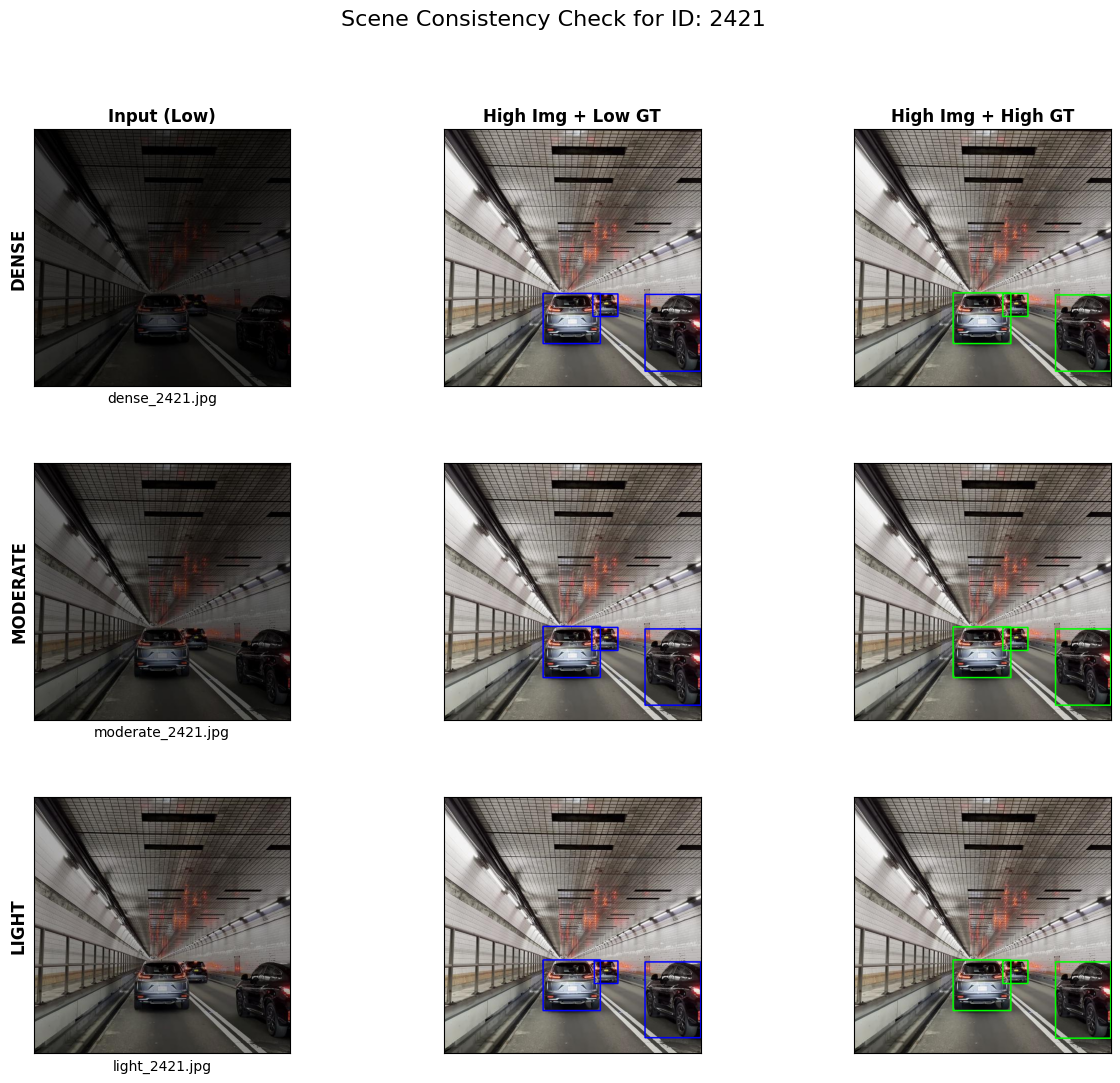

In [ ]:
# --- CONFIGURATION ---
train_root = 'Train' 
train_GT_root = 'YOLO Annotations/Train'
low_img_dir = os.path.join(train_root, 'low')
high_img_dir = os.path.join(train_root, 'high')
low_gt_dir = os.path.join(train_GT_root, 'low/Labels')
high_gt_dir = os.path.join(train_GT_root, 'high/Labels')

def draw_bboxes_on_image(img, label_path, color=(0, 255, 0)):
    """Helper to draw boxes on an image copy"""
    img_copy = img.copy()
    if os.path.exists(label_path):
        h, w, _ = img.shape
        with open(label_path, 'r') as f:
            for line in f.readlines():
                try:
                    parts = line.split()
                    if len(parts) < 5: continue
                    cls, x, y, nw, nh = map(float, parts)
                    
                    # YOLO to Pixel coords
                    x1 = int((x - nw/2) * w)
                    y1 = int((y - nh/2) * h)
                    x2 = int((x + nw/2) * w)
                    y2 = int((y + nh/2) * h)
                    
                    cv2.rectangle(img_copy, (x1, y1), (x2, y2), color, 2)
                except ValueError:
                    continue
    return img_copy

def check_scene_consistency():
    # 1. Pick a random number
    rand_id = random.randint(1, 10000) # Adjust range if your dataset is smaller/larger
    print(f"Checking Scene ID: {rand_id}...")
    
    illum_types = ['dense', 'moderate', 'light']
    
    # Setup 3x3 Plot
    fig, axs = plt.subplots(3, 3, figsize=(15, 12))
    plt.subplots_adjust(hspace=0.3)
    
    # Column Headers
    cols = ["Input (Low)", "High Img + Low GT", "High Img + High GT"]
    for ax, col in zip(axs[0], cols):
        ax.set_title(col, fontsize=12, fontweight='bold')

    for i, illum in enumerate(illum_types):
        # Construct filename: e.g., "dense_450.jpg"
        filename = f"{illum}_{rand_id}.jpg"
        label_filename = f"{illum}_{rand_id}.txt"
        
        # Define Paths
        p_low_img = os.path.join(low_img_dir, filename)
        p_high_img = os.path.join(high_img_dir, filename)
        p_low_gt = os.path.join(low_gt_dir, label_filename)
        p_high_gt = os.path.join(high_gt_dir, label_filename)
        
        # --- ROW LABEL (Illumination Type) ---
        axs[i, 0].set_ylabel(illum.upper(), rotation=90, size='large', fontweight='bold')

        # Check if files exist
        if not os.path.exists(p_low_img):
            axs[i, 1].text(0.5, 0.5, f"{filename}\nNOT FOUND", ha='center', va='center', fontsize=12, color='red')
            for j in range(3): axs[i, j].axis('off')
            continue
            
        # Load Images
        img_low = cv2.imread(p_low_img)
        img_high = cv2.imread(p_high_img) # This is the MOMENT OF TRUTH. 
        
        # 1. Plot Low Input
        axs[i, 0].imshow(cv2.cvtColor(img_low, cv2.COLOR_BGR2RGB))
        axs[i, 0].set_xlabel(filename)
        
        # 2. Plot High Img + Low GT (Red Boxes)
        if img_high is not None:
            vis_low_gt = draw_bboxes_on_image(img_high, p_low_gt, color=(255, 0, 0)) # Red
            axs[i, 1].imshow(cv2.cvtColor(vis_low_gt, cv2.COLOR_BGR2RGB))
        else:
            axs[i, 1].text(0.5, 0.5, "High Img Missing", ha='center')

        # 3. Plot High Img + High GT (Green Boxes)
        if img_high is not None:
            vis_high_gt = draw_bboxes_on_image(img_high, p_high_gt, color=(0, 255, 0)) # Green
            axs[i, 2].imshow(cv2.cvtColor(vis_high_gt, cv2.COLOR_BGR2RGB))
        else:
            axs[i, 2].text(0.5, 0.5, "High Img Missing", ha='center')
            
        # Hide axis ticks
        for j in range(3):
            axs[i, j].set_xticks([])
            axs[i, j].set_yticks([])

    plt.suptitle(f"Scene Consistency Check for ID: {rand_id}", fontsize=16)
    plt.show()

# Run it
check_scene_consistency()

In [ ]:
# --- CONFIGURATION ---
# Path to your image directory (containing all light/mod/dense images)
train_low_dir = os.path.join('Train', 'low') 

# Path to your curated CSV
csv_path = 'curated_dataset.csv'

def verify_completeness():
    if not os.path.exists(csv_path):
        print("CSV file not found.")
        return

    df = pd.read_csv(csv_path)
    
    # Filter for 'dense' just in case the CSV has mixed types
    dense_files = df[df['illumination'].str.lower() == 'dense']['filename'].tolist()
    
    missing_log = []
    
    print(f"Checking {len(dense_files)} curated 'Dense' images for counterparts...")
    
    for dense_fname in dense_files:
        # 1. Extract the numeric ID
        # Assumes format: "dense_123.jpg" -> id = "123"
        base_name = os.path.splitext(dense_fname)[0] # "dense_123"
        try:
            img_id = base_name.split('_')[-1] # "123"
        except IndexError:
            print(f"Skipping malformed filename: {dense_fname}")
            continue
            
        # 2. Construct target filenames
        mod_fname = f"moderate_{img_id}.jpg"
        light_fname = f"light_{img_id}.jpg"
        
        # 3. Check existence
        path_mod = os.path.join(train_low_dir, mod_fname)
        path_light = os.path.join(train_low_dir, light_fname)
        
        if not os.path.exists(path_mod):
            missing_log.append(mod_fname)
        
        if not os.path.exists(path_light):
            missing_log.append(light_fname)
            
    # --- REPORTING ---
    print("-" * 30)
    if len(missing_log) == 0:
        print("✅ SUCCESS: All corresponding images exist!")
        print(f"Every one of your {len(dense_files)} dense images has a matching Moderate and Light partner.")
    else:
        print(f"❌ WARNING: {len(missing_log)} matching images are missing.")
        print("First 10 missing files:")
        for f in missing_log[:10]:
            print(f" - {f}")

verify_completeness()

Checking 1700 curated 'Dense' images for counterparts...
------------------------------
✅ SUCCESS: All corresponding images exist!
Every one of your 1700 dense images has a matching Moderate and Light partner.


Val and Test Curation

In [3]:
val_checker = DatasetChecker(
    low_img_dir=os.path.join(val_root, 'low'), 
    high_img_dir=os.path.join(val_root, 'high'), 
    low_gt_dir=os.path.join(val_GT_root, 'YOLO Annotations (low)/Labels'), 
    high_gt_dir=os.path.join(val_GT_root, 'YOLO Annotations (high)/Labels'),
    output_csv='val_curated_dataset.csv',
    illum_type="dense"  # <--- NEW PARAMETER HERE
)

Loaded 100 previously saved annotations from CSV.
Found 900 remaining 'dense' images to check.


In [5]:
val_checker.export_csv()

Manifest saved to val_curated_dataset.csv
